In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Dubai Real Estate Project 🚀")


Dubai Real Estate Project 🚀


In [3]:
df=pd.read_csv("../data/dubai_properties.csv")
df["Type"].value_counts()



Type
Apartment               56534
Villa                   12883
Townhouse                3421
Hotel Apartment           465
Penthouse                 270
Villa Compound            107
Residential Building       44
Residential Floor          12
Residential Plot            6
Name: count, dtype: int64

In [4]:
# أقل وأعلى القيم حتى نكتشف الحالات الغريبة
df[["Rent", "Area_in_sqft", "Rent_per_sqft", "Beds", "Baths"]].agg(["min", "max"])

,Rent,Area_in_sqft,Rent_per_sqft,Beds,Baths
min,0,74,0.000000,0,1
max,55000000,210254,2182.044888,12,11


In [5]:
df[["Rent", "Beds", "Baths", "Area_in_sqft", "Rent_per_sqft"]].describe()

,Rent,Beds,Baths,Area_in_sqft,Rent_per_sqft
count,7.374200e+04,73742.000000,73742.000000,73742.000000,73742.000000
mean,1.479250e+05,2.162811,2.650213,2054.053552,88.057754
std,3.069658e+05,1.578155,1.632997,3003.919252,66.534400
min,0.000000e+00,0.000000,1.000000,74.000000,0.000000
25%,5.499900e+04,1.000000,2.000000,850.000000,39.977778
50%,9.800000e+04,2.000000,2.000000,1334.000000,71.428571
75%,1.700000e+05,3.000000,3.000000,2130.000000,118.483412
max,5.500000e+07,12.000000,11.000000,210254.000000,2182.044888


In [6]:
df.isnull().sum()

Address                     0
Rent                        0
Beds                        0
Baths                       0
Type                        0
Area_in_sqft                0
Rent_per_sqft               0
Rent_category               0
Frequency                   0
Furnishing                  0
Purpose                     0
Posted_date                 0
Age_of_listing_in_days      0
Location                    0
City                        0
Latitude                  719
Longitude                 719
dtype: int64

In [7]:
df["Type"].value_counts()

Type
Apartment               56534
Villa                   12883
Townhouse                3421
Hotel Apartment           465
Penthouse                 270
Villa Compound            107
Residential Building       44
Residential Floor          12
Residential Plot            6
Name: count, dtype: int64

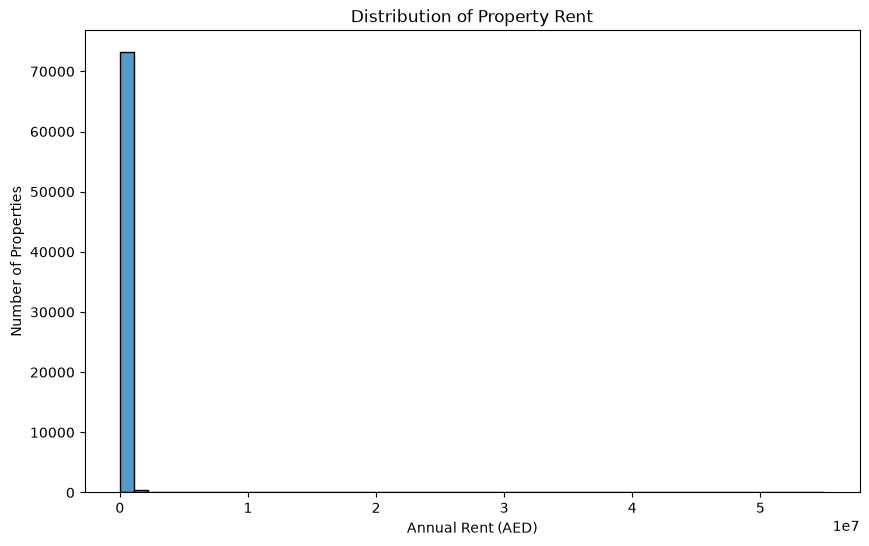

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(df["Rent"].dropna(), bins=50)

plt.title("Distribution of Property Rent")
plt.xlabel("Annual Rent (AED)")
plt.ylabel("Number of Properties")

plt.show()

In [9]:
df.groupby("Location")["Rent"].mean().sort_values(ascending=False).head(10)

Location
Emirates Hills                 2.147740e+06
Knowledge Village              1.859550e+06
Dubai Investment Park (DIP)    1.474200e+06
Jumeirah Islands               1.327426e+06
Nareel Island                  9.000000e+05
Al Barari                      8.937574e+05
Al Hebiah 2                    7.900000e+05
Al Twar                        6.499999e+05
Jumeirah Golf Estates          6.348644e+05
Bluewaters Island              6.228379e+05
Name: Rent, dtype: float64

In [10]:
# عدد ونسبة العقارات ذات الإيجار صفر
zero_rent = df[df["Rent"] == 0]

print("Number of zero-rent listings:", len(zero_rent))
print("Percentage:", round(len(zero_rent) / len(df) * 100, 2), "%")

# عرض عينة لفهم هذه السجلات
zero_rent[
    ["Address", "Rent", "Beds", "Baths", "Type",
     "Area_in_sqft", "Rent_per_sqft", "Location", "City"]
].head(10)

Number of zero-rent listings: 15
Percentage: 0.02 %


,Address,Rent,Beds,Baths,Type,Area_in_sqft,Rent_per_sqft,Location,City
32240,"Al Barsha South 2, Al Barsha South, Al Barsha,...",0,5,2,Villa,10000,0.0,Al Barsha,Dubai
32241,"Port Saeed, Deira, Dubai",0,1,2,Apartment,750,0.0,Deira,Dubai
32242,"Port Saeed, Deira, Dubai",0,1,2,Apartment,850,0.0,Deira,Dubai
32243,"Park Gate Residence A, Park Gate Residence, Al...",0,2,2,Apartment,1554,0.0,Bur Dubai,Dubai
32631,"Al Barsha South 2, Al Barsha South, Al Barsha,...",0,5,2,Villa,12500,0.0,Al Barsha,Dubai
32632,"Abu Hail, Deira, Dubai",0,5,2,Villa,4500,0.0,Deira,Dubai
32633,"Al Barsha 3, Al Barsha, Dubai",0,1,2,Apartment,750,0.0,Al Barsha,Dubai
34160,"Al Khudrawi, Shoreline Apartments, Palm Jumeir...",0,2,2,Apartment,1551,0.0,Palm Jumeirah,Dubai
35389,"Serenia Residences West Wing, Serenia Residenc...",0,4,2,Apartment,2885,0.0,Palm Jumeirah,Dubai
56079,"1 Residences, Wasl 1, Al Kifaf, Bur Dubai, Dubai",0,2,2,Apartment,1439,0.0,Bur Dubai,Dubai


In [11]:
# إنشاء نسخة نظيفة بدون سجلات الإيجار صفر أو السالب
df_clean = df[df["Rent"] > 0].copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Original shape: (73742, 17)
Cleaned shape: (73727, 17)
Rows removed: 15


In [12]:
print("Rent_per_sqft <= 0:", (df_clean["Rent_per_sqft"] <= 0).sum())

df_clean[
    ["Rent", "Area_in_sqft", "Rent_per_sqft", "Beds", "Baths", "Type"]
].describe()

Rent_per_sqft <= 0: 0


,Rent,Area_in_sqft,Rent_per_sqft,Beds,Baths
count,7.372700e+04,73727.000000,73727.000000,73727.000000,73727.000000
mean,1.479551e+05,2053.708329,88.075670,2.162654,2.650345
std,3.069898e+05,3003.723434,66.529310,1.578127,1.633137
min,1.000000e+00,74.000000,0.000556,0.000000,1.000000
25%,5.499900e+04,850.000000,39.989975,1.000000,2.000000
50%,9.800000e+04,1334.000000,71.428571,2.000000,2.000000
75%,1.700000e+05,2130.000000,118.483412,3.000000,3.000000
max,5.500000e+07,210254.000000,2182.044888,12.000000,11.000000


In [13]:
# معرفة أنواع دورية الإيجار الموجودة
print(df_clean["Frequency"].value_counts())

# مقارنة الإيجارات حسب دورية الدفع
df_clean.groupby("Frequency")["Rent"].agg(
    count="count",
    min="min",
    median="median",
    max="max"
).sort_values("count", ascending=False)

Frequency
Yearly    73727
Name: count, dtype: int64


,count,min,median,max
Frequency,,,,
Yearly,73727,1,98000.0,55000000


In [14]:
df_clean.loc[
    df_clean["Rent"] <= 1000,
    ["Address", "Rent", "Frequency", "Type",
     "Beds", "Baths", "Area_in_sqft", "Location"]
].sort_values("Rent").head(20)

,Address,Rent,Frequency,Type,Beds,Baths,Area_in_sqft,Location
71007,"Lootah Al Nahda, Al Nahda (Sharjah), Sharjah",1,Yearly,Apartment,2,2,1500,Al Nahda (Sharjah)
71562,"Al Taawun, Sharjah",1,Yearly,Apartment,2,3,1800,Al Taawun
58313,"The Address Residences Dubai Opera, Downtown D...",290,Yearly,Apartment,2,2,1250,Downtown Dubai


In [15]:
# نسب مئوية من توزيع الإيجارات السنوية
df_clean["Rent"].quantile([0.001, 0.005, 0.01, 0.025, 0.05, 0.95, 0.99, 0.999])

0.001      11000.0
0.005      14000.0
0.010      15999.0
0.025      21600.0
0.050      26000.0
0.950     390000.0
0.990     990000.0
0.999    2900000.0
Name: Rent, dtype: float64

In [16]:
# افحص كل العقارات ذات الإيجار الأقل من 5,000 AED سنويًا
low_rent = df_clean[df_clean["Rent"] < 5000]

print("Listings under 5,000 AED/year:", len(low_rent))

low_rent[
    ["Address", "Rent", "Type", "Beds", "Baths",
     "Area_in_sqft", "Rent_per_sqft", "Location", "City"]
].sort_values("Rent")

Listings under 5,000 AED/year: 3


,Address,Rent,Type,Beds,Baths,Area_in_sqft,Rent_per_sqft,Location,City
71007,"Lootah Al Nahda, Al Nahda (Sharjah), Sharjah",1,Apartment,2,2,1500,0.000667,Al Nahda (Sharjah),Sharjah
71562,"Al Taawun, Sharjah",1,Apartment,2,3,1800,0.000556,Al Taawun,Sharjah
58313,"The Address Residences Dubai Opera, Downtown D...",290,Apartment,2,2,1250,0.232000,Downtown Dubai,Dubai


In [17]:
# استبعاد الإيجارات السنوية غير الواقعية
df_clean = df_clean[df_clean["Rent"] >= 5000].copy()

print("Cleaned shape:", df_clean.shape)
print("Rent below 5,000 remaining:", (df_clean["Rent"] < 5000).sum())
print("Minimum valid rent:", df_clean["Rent"].min())

Cleaned shape: (73724, 17)
Rent below 5,000 remaining: 0
Minimum valid rent: 7500


In [18]:
# التكرار الكامل: هل يوجد صف مطابق تمامًا لصف آخر؟
print("Exact duplicate rows:", df_clean.duplicated().sum())

Exact duplicate rows: 0


In [19]:
# فحص الإحداثيات الناقصة
missing_geo = df_clean[["Latitude", "Longitude"]].isna()

print("Missing Latitude:", missing_geo["Latitude"].sum())
print("Missing Longitude:", missing_geo["Longitude"].sum())

# هل كل سجل ناقص Latitude ناقص Longitude أيضًا؟
print(
    "Rows with one coordinate missing but not the other:",
    (missing_geo["Latitude"] != missing_geo["Longitude"]).sum()
)

# المدن الموجودة وعدد الإعلانات في كل مدينة
df_clean["City"].value_counts()

Missing Latitude: 719
Missing Longitude: 719
Rows with one coordinate missing but not the other: 0


City
Dubai             34235
Abu Dhabi         23324
Sharjah            9513
Ajman              4704
Al Ain             1040
Ras Al Khaimah      816
Umm Al Quwain        65
Fujairah             27
Name: count, dtype: int64

In [20]:
# التأكد من أن جميع السجلات هدفها الإيجار
df_clean["Purpose"].value_counts()

Purpose
For Rent    73724
Name: count, dtype: int64

In [21]:
# نسخة مشروع دبي فقط
df_dubai = df_clean[df_clean["City"] == "Dubai"].copy()

print("Dubai dataset shape:", df_dubai.shape)
print("Dubai listings:", len(df_dubai))
print(
    "Listings without coordinates:",
    df_dubai[["Latitude", "Longitude"]].isna().any(axis=1).sum()
)

Dubai dataset shape: (34235, 17)
Dubai listings: 34235
Listings without coordinates: 31


In [22]:
# ملخص الإيجارات السنوية حسب نوع العقار في دبي
type_summary = (
    df_dubai.groupby("Type")["Rent"]
    .agg(
        Listings="count",
        Average_Rent="mean",
        Median_Rent="median",
        Min_Rent="min",
        Max_Rent="max"
    )
    .sort_values("Median_Rent", ascending=False)
)

type_summary.round(0)

,Listings,Average_Rent,Median_Rent,Min_Rent,Max_Rent
Type,,,,,
Residential Building,11,7780000.0,4200000.0,280000,55000000
Residential Floor,10,1679692.0,1829775.0,420000,2211075
Residential Plot,2,725000.0,725000.0,250000,1200000
Penthouse,153,710802.0,500000.0,74900,3800000
Villa Compound,17,349941.0,370000.0,105000,520000
Villa,5089,465068.0,300000.0,43000,16000000
Hotel Apartment,450,230240.0,177000.0,50000,1300000
Townhouse,2358,198402.0,175000.0,60000,2500000
Apartment,26145,158772.0,120000.0,17000,4000000


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_38868\4289763822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


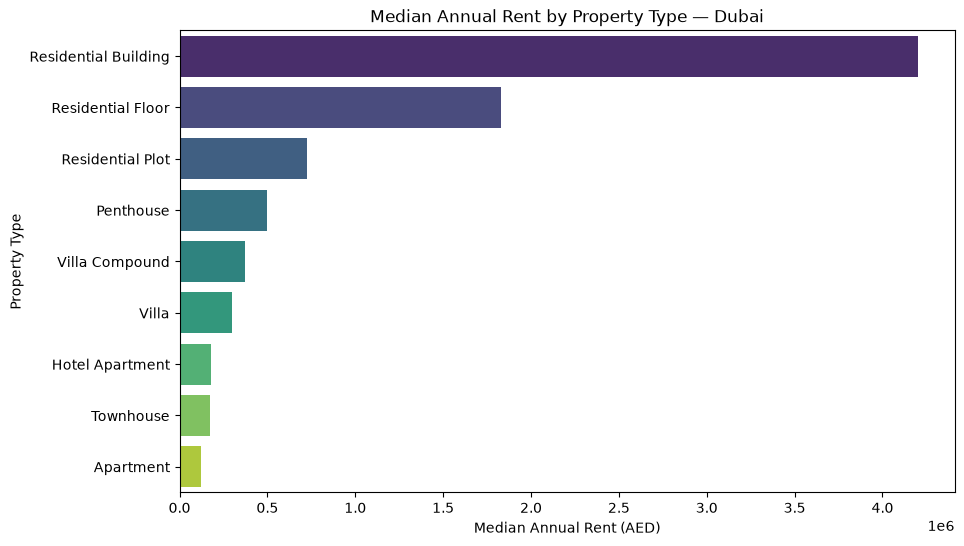

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=type_summary.reset_index(),
    x="Median_Rent",
    y="Type",
    palette="viridis"
)

plt.title("Median Annual Rent by Property Type — Dubai")
plt.xlabel("Median Annual Rent (AED)")
plt.ylabel("Property Type")
plt.show()

In [24]:
# ملخص الإيجارات حسب المنطقة
location_summary = (
    df_dubai.groupby("Location")["Rent"]
    .agg(
        Listings="count",
        Average_Rent="mean",
        Median_Rent="median"
    )
)

# نحتفظ فقط بالمناطق التي لها 30 إعلانًا أو أكثر
# حتى لا تؤثر منطقة فيها إعلان أو إعلانان فقط
location_summary = location_summary[location_summary["Listings"] >= 30]

# أعلى 10 مناطق بحسب وسيط الإيجار السنوي
top_areas = location_summary.sort_values("Median_Rent", ascending=False).head(10)

top_areas.round(0)

,Listings,Average_Rent,Median_Rent
Location,,,
Jumeirah Islands,68,1327426.0,1000000.0
Al Barari,66,893757.0,875000.0
Bluewaters Island,192,622838.0,527500.0
Jumeirah Golf Estates,96,634864.0,450000.0
The Meadows,132,516765.0,425000.0
Jumeirah Park,257,420677.0,390000.0
Arabian Ranches,178,390899.0,350000.0
Jumeirah,367,485517.0,350000.0
The Villa,96,398832.0,344500.0


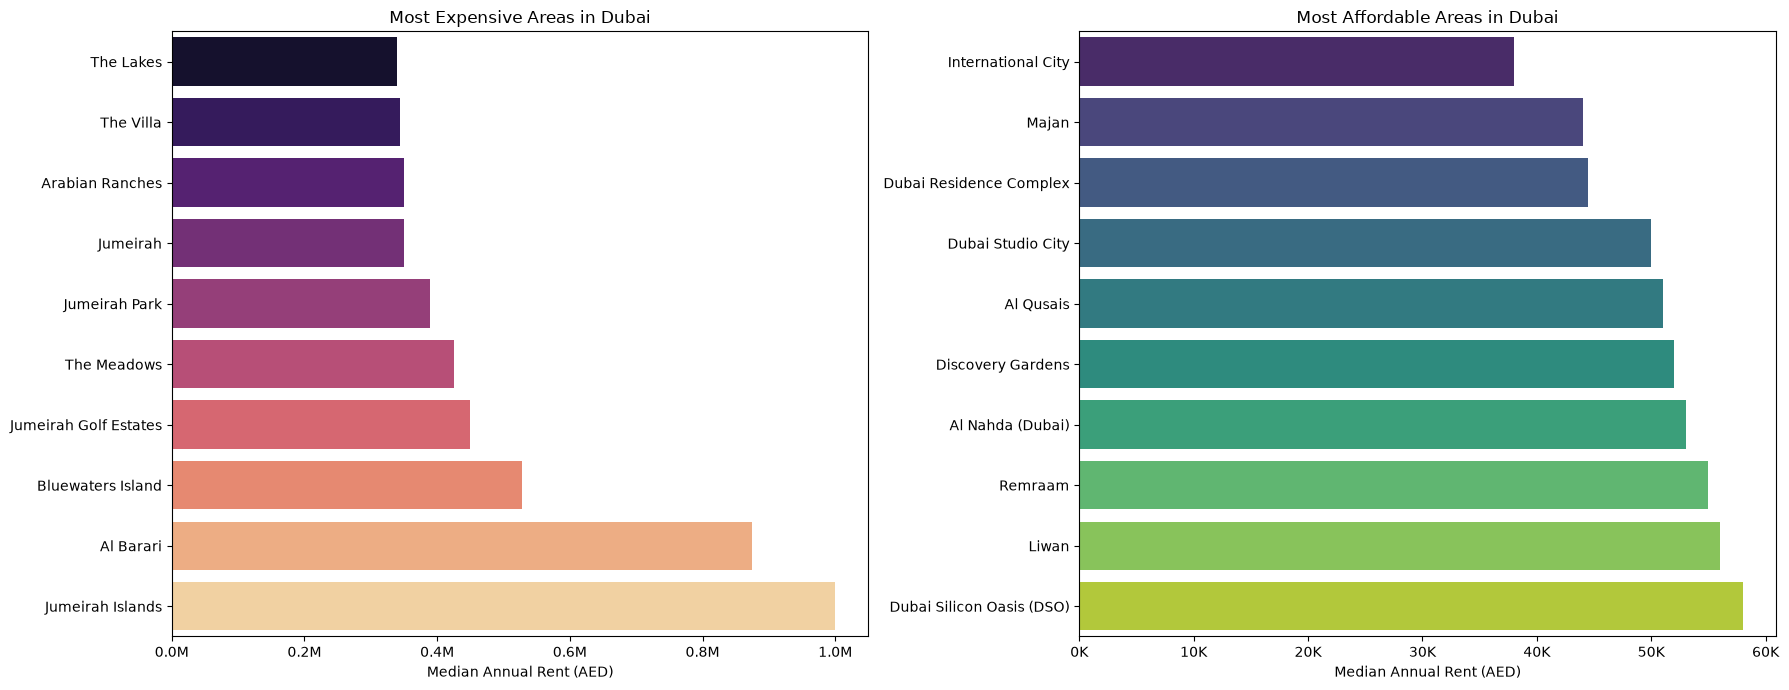

In [25]:
from matplotlib.ticker import FuncFormatter

# أرخص 10 مناطق من حيث وسيط الإيجار
bottom_areas = location_summary.sort_values("Median_Rent").head(10)

# تجهيز الترتيب للرسم الأفقي
top_plot = top_areas.sort_values("Median_Rent")
bottom_plot = bottom_areas.sort_values("Median_Rent")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=top_plot.reset_index(),
    x="Median_Rent",
    y="Location",
    hue="Location",
    palette="magma",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Most Expensive Areas in Dubai")
axes[0].set_xlabel("Median Annual Rent (AED)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:.1f}M")
)

sns.barplot(
    data=bottom_plot.reset_index(),
    x="Median_Rent",
    y="Location",
    hue="Location",
    palette="viridis",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Most Affordable Areas in Dubai")
axes[1].set_xlabel("Median Annual Rent (AED)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000:.0f}K")
)

plt.tight_layout()
plt.show()

In [26]:
# ملخص الإيجار حسب عدد غرف النوم
bedroom_summary = (
    df_dubai.groupby("Beds")["Rent"]
    .agg(
        Listings="count",
        Average_Rent="mean",
        Median_Rent="median"
    )
    .sort_index()
)

# نعرض فقط الفئات التي لديها 30 إعلانًا أو أكثر
bedroom_plot = bedroom_summary[bedroom_summary["Listings"] >= 30]

bedroom_plot.round(0)

,Listings,Average_Rent,Median_Rent
Beds,,,
0,4186,59356.0,50000.0
1,10462,109547.0,97000.0
2,8949,192954.0,170000.0
3,5918,260505.0,225000.0
4,2961,392325.0,280000.0
5,1273,630047.0,425000.0
6,349,1151352.0,820000.0
7,101,1416525.0,800000.0


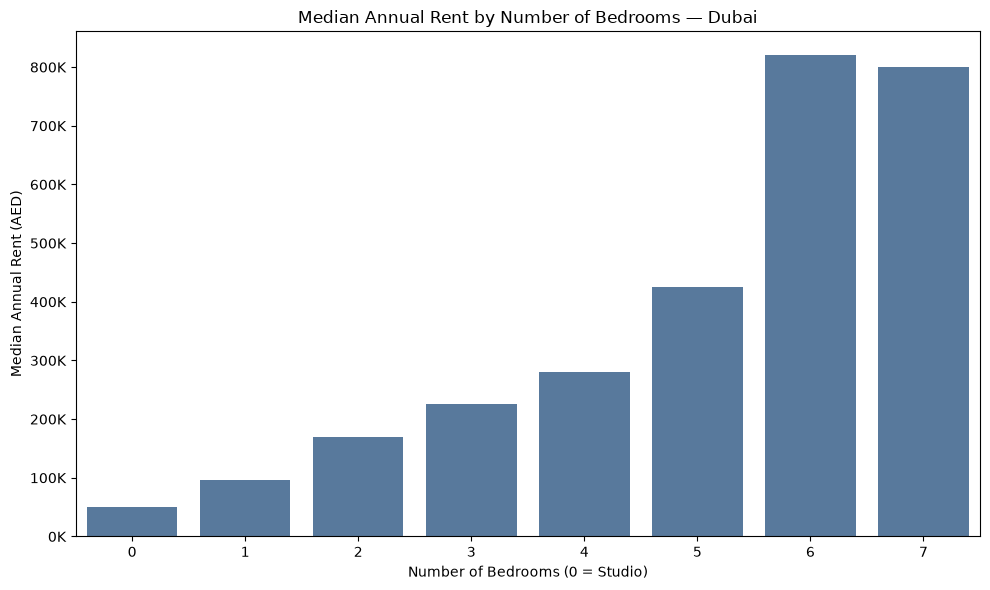

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=bedroom_plot.reset_index(),
    x="Beds",
    y="Median_Rent",
    color="#4C78A8"
)

plt.title("Median Annual Rent by Number of Bedrooms — Dubai")
plt.xlabel("Number of Bedrooms (0 = Studio)")
plt.ylabel("Median Annual Rent (AED)")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000:.0f}K")
)

plt.tight_layout()
plt.show()

In [28]:
# تكلفة القدم المربع حسب المنطقة
value_summary = (
    df_dubai.groupby("Location")
    .agg(
        Listings=("Rent", "count"),
        Median_Rent=("Rent", "median"),
        Median_Rent_per_sqft=("Rent_per_sqft", "median")
    )
)

# نستخدم مناطق لها 30 إعلانًا أو أكثر
value_summary = value_summary[value_summary["Listings"] >= 30]

# الأعلى والأقل تكلفة لكل قدم مربع
most_expensive_per_sqft = value_summary.sort_values(
    "Median_Rent_per_sqft", ascending=False
).head(10)

best_value_per_sqft = value_summary.sort_values(
    "Median_Rent_per_sqft", ascending=True
).head(10)

print("Highest median rent per sqft:")
display(most_expensive_per_sqft.round(2))

print("Lowest median rent per sqft:")
display(best_value_per_sqft.round(2))

Highest median rent per sqft:


,Listings,Median_Rent,Median_Rent_per_sqft
Location,,,
Bluewaters Island,192,527500.0,317.37
Dubai Harbour,460,249999.5,218.88
Downtown Dubai,3002,218000.0,183.44
Za'abeel,446,217450.0,168.38
Jumeirah,367,350000.0,163.36
Jumeirah Islands,68,1000000.0,163.13
Al Wasl,77,280000.0,161.89
Palm Jumeirah,1609,250000.0,160.82
Dubai Creek Harbour,1736,170000.0,156.69


Lowest median rent per sqft:


,Listings,Median_Rent,Median_Rent_per_sqft
Location,,,
Al Awir,38,230000.0,19.30
Al Khawaneej,45,300000.0,30.57
Mirdif,205,130000.0,44.00
Living Legends,34,297500.0,44.55
Al Quoz,54,65000.0,50.00
Falcon City of Wonders,31,300000.0,51.12
Nad Al Sheba,128,297000.0,53.43
Al Qusais,50,51000.0,53.71
Al Nahda (Dubai),185,53000.0,54.92


In [29]:
df_dubai.nlargest(10, "Area_in_sqft")[
    ["Address", "Rent", "Type", "Beds", "Baths", "Area_in_sqft", "Location"]
]

,Address,Rent,Type,Beds,Baths,Area_in_sqft,Location
57236,"Marina Residences 1, Marina Residences, Palm J...",900000,Penthouse,4,2,210254,Palm Jumeirah
62394,"One Za'abeel The Residences, One Za'abeel, Za'...",1200000,Residential Plot,1,1,173565,Za'abeel
56445,"Jumeirah Village Triangle (JVT), Dubai",299999,Villa,6,2,168046,Jumeirah Village Triangle (JVT)
59998,"Hor Al Anz East, Hor Al Anz, Deira, Dubai",8000000,Residential Building,2,2,135774,Deira
56785,"Dubai Investment Park 1, Dubai Investment Park...",55000000,Residential Building,11,2,129576,Dubai Investment Park (DIP)
57810,"Jumeirah 3, Jumeirah, Dubai",420000,Villa Compound,5,2,123696,Jumeirah
58134,"International City Phase 2 (Warsan 4), Interna...",4600000,Residential Building,11,2,108575,International City
61139,"Jumeirah 1, Jumeirah, Dubai",1800000,Villa,11,2,46474,Jumeirah
58257,"Al Manara, Dubai",400000,Villa,5,2,40000,Al Manara
54991,"Al Jafiliya, Dubai",275000,Villa Compound,5,2,39733,Al Jafiliya


In [30]:
df_dubai.nlargest(10, "Rent")[
    ["Address", "Rent", "Type", "Beds", "Baths", "Area_in_sqft", "Location"]
]

,Address,Rent,Type,Beds,Baths,Area_in_sqft,Location
56785,"Dubai Investment Park 1, Dubai Investment Park...",55000000,Residential Building,11,2,129576,Dubai Investment Park (DIP)
31677,"Signature Villas Frond H, Signature Villas Pal...",16000000,Villa,10,2,23745,Palm Jumeirah
55471,"Frond J, Palm Jumeirah, Dubai",12000000,Villa,10,2,30776,Palm Jumeirah
59998,"Hor Al Anz East, Hor Al Anz, Deira, Dubai",8000000,Residential Building,2,2,135774,Deira
43415,"Signature Villas Frond G, Signature Villas Pal...",6000000,Villa,8,2,9500,Palm Jumeirah
58646,"Signature Villas Frond G, Signature Villas Pal...",6000000,Villa,8,2,9505,Palm Jumeirah
53574,"Signature Villas Frond L, Signature Villas Pal...",5700000,Villa,7,2,13404,Palm Jumeirah
60704,"Signature Villas Frond L, Signature Villas Pal...",5700000,Villa,7,2,7000,Palm Jumeirah
60733,"Signature Villas Frond L, Signature Villas Pal...",5500000,Villa,7,2,13404,Palm Jumeirah
61023,"Signature Villas Frond L, Signature Villas Pal...",5500000,Villa,7,2,13404,Palm Jumeirah


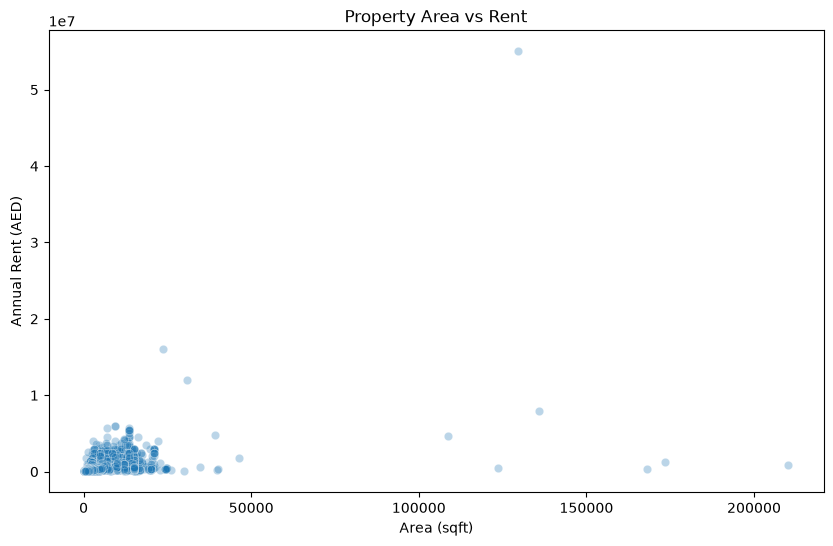

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_dubai,
    x="Area_in_sqft",
    y="Rent",
    alpha=0.3
)

plt.title("Property Area vs Rent")
plt.xlabel("Area (sqft)")
plt.ylabel("Annual Rent (AED)")

plt.show()

In [32]:
df_dubai[["Area_in_sqft", "Rent"]].corr()

,Area_in_sqft,Rent
Area_in_sqft,1.000000,0.498603
Rent,0.498603,1.000000


In [33]:
df_normal = df_dubai[
    (df_dubai["Area_in_sqft"] <= 10000) &
    (df_dubai["Rent"] <= 1000000)
]

print(df_normal.shape)

(33240, 17)


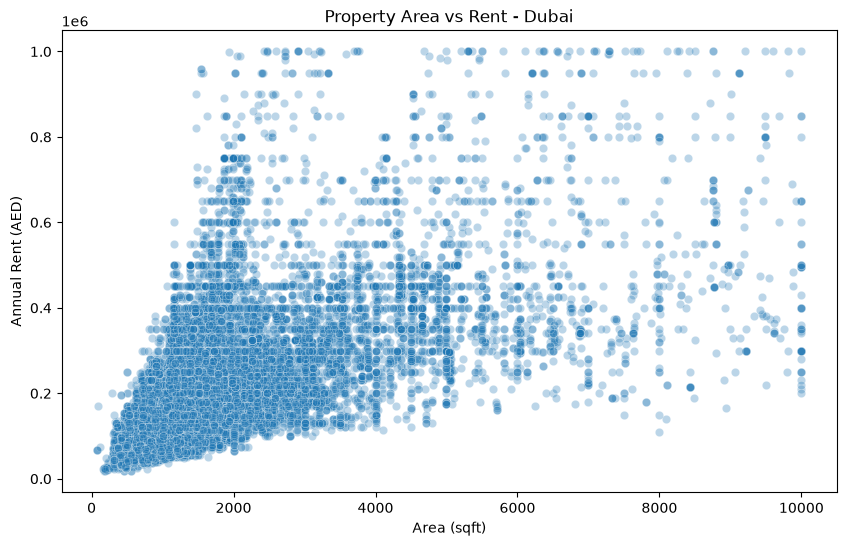

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_normal,
    x="Area_in_sqft",
    y="Rent",
    alpha=0.3
)

plt.title("Property Area vs Rent - Dubai")
plt.xlabel("Area (sqft)")
plt.ylabel("Annual Rent (AED)")

plt.show()

In [35]:
df_dubai.groupby("Beds")["Rent"].mean().sort_values(ascending=False)

Beds
11    7.015455e+06
10    4.425000e+06
8     2.148499e+06
7     1.416525e+06
6     1.151352e+06
9     8.571429e+05
5     6.300465e+05
12    6.000000e+05
4     3.923249e+05
3     2.605046e+05
2     1.929536e+05
1     1.095472e+05
0     5.935569e+04
Name: Rent, dtype: float64

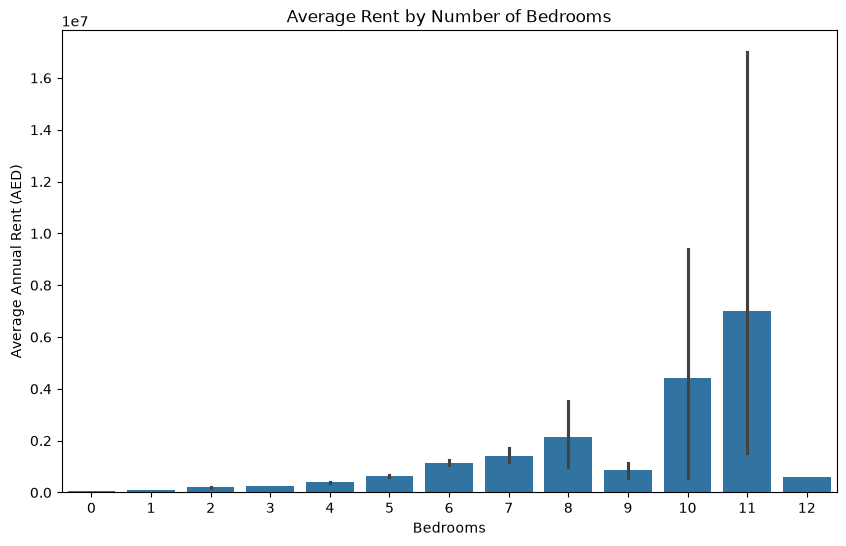

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_dubai,
    x="Beds",
    y="Rent",
    estimator="mean"
)

plt.title("Average Rent by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Annual Rent (AED)")

plt.show()

In [37]:
df_dubai["Beds"].value_counts().sort_index()

Beds
0      4186
1     10462
2      8949
3      5918
4      2961
5      1273
6       349
7       101
8        10
9         7
10        7
11       11
12        1
Name: count, dtype: int64

In [38]:
df_dubai.groupby("Beds")["Rent"].agg(["count", "mean", "median"]).round(0)

,count,mean,median
Beds,,,
0,4186,59356.0,50000.0
1,10462,109547.0,97000.0
2,8949,192954.0,170000.0
3,5918,260505.0,225000.0
4,2961,392325.0,280000.0
5,1273,630047.0,425000.0
6,349,1151352.0,820000.0
7,101,1416525.0,800000.0
8,10,2148499.0,1399995.0


In [39]:
df_model = df_dubai[df_dubai["Beds"] <= 7].copy()

print("Original data:", df_dubai.shape)
print("Model data:", df_model.shape)

Original data: (34235, 17)
Model data: (34199, 17)


In [40]:
df_model["Beds"].value_counts().sort_index()

Beds
0     4186
1    10462
2     8949
3     5918
4     2961
5     1273
6      349
7      101
Name: count, dtype: int64

In [41]:
df_model.groupby("Type")["Rent"].agg(["count", "mean", "median"]).sort_values(
    "median", ascending=False
).round(0)

,count,mean,median
Type,,,
Residential Building,4,3190000.0,2240000.0
Residential Floor,10,1679692.0,1829775.0
Residential Plot,2,725000.0,725000.0
Penthouse,153,710802.0,500000.0
Villa Compound,17,349941.0,370000.0
Villa,5060,455202.0,300000.0
Hotel Apartment,450,230240.0,177000.0
Townhouse,2358,198402.0,175000.0
Apartment,26145,158772.0,120000.0


In [42]:
df_model.groupby("Furnishing")["Rent"].agg(["count", "mean", "median"]).sort_values(
    "median", ascending=False
).round(0)

,count,mean,median
Furnishing,,,
Furnished,13236,220215.0,145000.0
Unfurnished,20963,203063.0,145000.0


In [43]:
df_model["Furnishing"].value_counts()

Furnishing
Unfurnished    20963
Furnished      13236
Name: count, dtype: int64

In [44]:
type_counts = df_model["Type"].value_counts()

common_types = type_counts[type_counts >= 100].index

df_type = df_model[df_model["Type"].isin(common_types)]

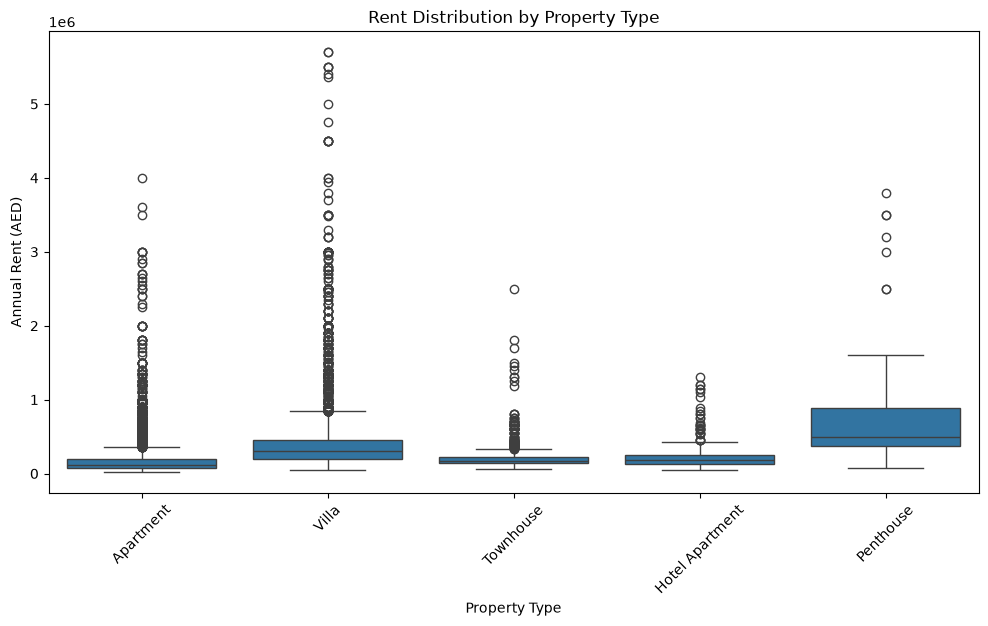

In [45]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_type,
    x="Type",
    y="Rent"
)

plt.title("Rent Distribution by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Annual Rent (AED)")
plt.xticks(rotation=45)

plt.show()

In [46]:
features = [
    "Beds",
    "Baths",
    "Type",
    "Area_in_sqft",
    "Furnishing",
    "Location"
]

target = "Rent"

X = df_model[features]
y = df_model[target]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (34199, 6)
Target: (34199,)


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (27359, 6)
Testing: (6840, 6)


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Type",
    "Furnishing",
    "Location"
    
]
numeric_features = [
    "Beds",
    "Baths",
    "Area_in_sqft"
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Beds','Baths','Type','Area_in_sqft','Furnishing','Location']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of co

In [50]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 173515.188       152078.72835498  422124.67476967  124500.62382062
   60520.11083333  145209.76190476  122712.51388889  475936.838
 1295800.           39031.198     ]


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.0f} AED")
print(f"RMSE: {rmse:,.0f} AED")
print(f"R²: {r2:.3f}")

MAE: 34,834 AED
RMSE: 122,882 AED
R²: 0.793


In [52]:
results = pd.DataFrame({
    "Actual_Rent": y_test.values,
    "Predicted_Rent": y_pred
})

results["Error"] = results["Actual_Rent"] - results["Predicted_Rent"]

results.head(10)

,Actual_Rent,Predicted_Rent,Error
0,150000,1.735152e+05,-23515.188000
1,149999,1.520787e+05,-2079.728355
2,380000,4.221247e+05,-42124.674770
3,130000,1.245006e+05,5499.376179
4,55000,6.052011e+04,-5520.110833
5,150000,1.452098e+05,4790.238095
6,110000,1.227125e+05,-12712.513889
7,550000,4.759368e+05,74063.162000
8,750000,1.295800e+06,-545800.000000
9,45000,3.903120e+04,5968.802000


In [53]:
results["Absolute_Error"] = results["Error"].abs()

results.nlargest(10, "Absolute_Error")

,Actual_Rent,Predicted_Rent,Error,Absolute_Error
5422,4000000,4.483743e+05,3.551626e+06,3.551626e+06
1917,5499999,3.370833e+06,2.129166e+06,2.129166e+06
6407,3300000,1.235000e+06,2.065000e+06,2.065000e+06
129,4000000,2.081500e+06,1.918500e+06,1.918500e+06
5153,4500000,2.638536e+06,1.861464e+06,1.861464e+06
3634,349900,2.088800e+06,-1.738900e+06,1.738900e+06
3676,1000000,2.721151e+06,-1.721151e+06,1.721151e+06
5680,3500000,1.936730e+06,1.563270e+06,1.563270e+06
3502,780000,2.317099e+06,-1.537099e+06,1.537099e+06
5699,395000,1.906896e+06,-1.511896e+06,1.511896e+06


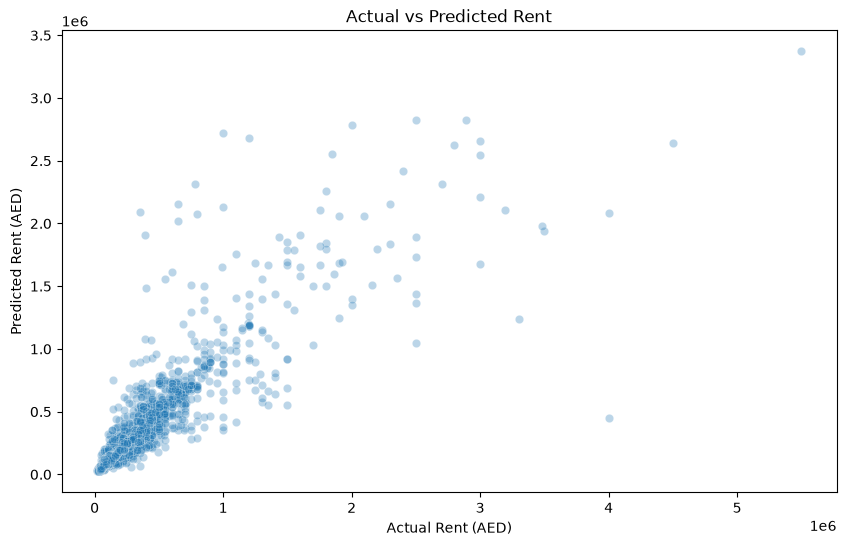

In [54]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=results["Actual_Rent"],
    y=results["Predicted_Rent"],
    alpha=0.3
)

plt.xlabel("Actual Rent (AED)")
plt.ylabel("Predicted Rent (AED)")
plt.title("Actual vs Predicted Rent")

plt.show()

In [55]:
results["Absolute_Percentage_Error"] = (
    results["Absolute_Error"] / results["Actual_Rent"]
) * 100

results["Absolute_Percentage_Error"].describe()
results.nlargest(10, "Absolute_Percentage_Error")

,Actual_Rent,Predicted_Rent,Error,Absolute_Error,Absolute_Percentage_Error
3634,349900,2.088800e+06,-1.738900e+06,1.738900e+06,496.970554
5451,145000,7.543902e+05,-6.093902e+05,6.093902e+05,420.269083
5699,395000,1.906896e+06,-1.511896e+06,1.511896e+06,382.758607
5032,400000,1.489275e+06,-1.089275e+06,1.089275e+06,272.318695
1976,140000,5.178088e+05,-3.778088e+05,3.778088e+05,269.863400
2607,650000,2.151457e+06,-1.501457e+06,1.501457e+06,230.993332
4433,100000,3.212251e+05,-2.212251e+05,2.212251e+05,221.225112
5076,48000,1.514338e+05,-1.034338e+05,1.034338e+05,215.487063
4164,55000,1.733642e+05,-1.183642e+05,1.183642e+05,215.207558
5080,650000,2.017514e+06,-1.367514e+06,1.367514e+06,210.386813


In [56]:
y_train_log = np.log1p(y_train)

In [57]:
model_log = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model_log.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Beds','Baths','Type','Area_in_sqft','Furnishing','Location']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of co

In [58]:
y_pred_log = model_log.predict(X_test)

y_pred_log_original = np.expm1(y_pred_log)

In [59]:
mae_log = mean_absolute_error(y_test, y_pred_log_original)
rmse_log = np.sqrt(
    mean_squared_error(y_test, y_pred_log_original)
)
r2_log = r2_score(y_test, y_pred_log_original)

print(f"MAE: {mae_log:,.0f} AED")
print(f"RMSE: {rmse_log:,.0f} AED")
print(f"R²: {r2_log:.3f}")

MAE: 33,465 AED
RMSE: 118,123 AED
R²: 0.808


In [60]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model_log,
    X_test,
    y_test_log if "y_test_log" in globals() else np.log1p(y_test),
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [61]:
importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

importance

Area_in_sqft    1.056687
Location        0.386501
Beds            0.187732
Furnishing      0.040593
Type            0.038907
Baths          -0.000121
dtype: float64

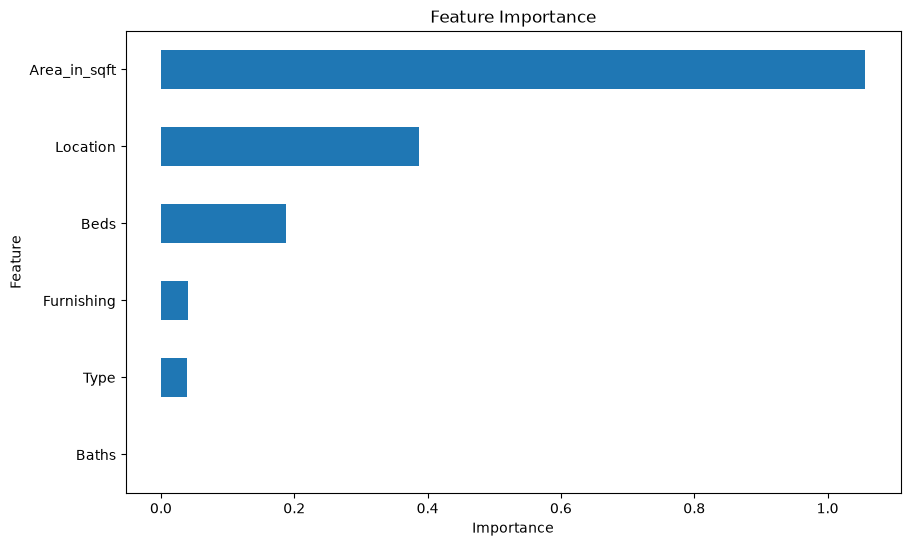

In [62]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [63]:
print("Purpose:")
print(df_model["Purpose"].value_counts())

print("\nFrequency:")
print(df_model["Frequency"].value_counts())

print(df_model[["Purpose", "Frequency", "Rent"]].head(10))

Purpose:
Purpose
For Rent    34199
Name: count, dtype: int64

Frequency:
Frequency
Yearly    34199
Name: count, dtype: int64
        Purpose Frequency    Rent
29068  For Rent    Yearly  125000
29069  For Rent    Yearly   50000
29070  For Rent    Yearly   90000
29071  For Rent    Yearly  125000
29072  For Rent    Yearly  105000
29073  For Rent    Yearly   90000
29074  For Rent    Yearly  360000
29075  For Rent    Yearly   50000
29076  For Rent    Yearly   80000
29077  For Rent    Yearly   90000


In [64]:
features_v2 = [
    "Beds",
    "Baths",
    "Type",
    "Area_in_sqft",
    "Furnishing",
    "Location",
    "Age_of_listing_in_days"
]

X_v2 = df_model[features_v2]
y_v2 = df_model["Rent"]

print(X_v2.shape)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=42
)

(34199, 7)


In [65]:
categorical_features_v2 = [
    "Type",
    "Furnishing",
    "Location"
]

numeric_features_v2 = [
    "Beds",
    "Baths",
    "Area_in_sqft",
    "Age_of_listing_in_days"
]

preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_v2
        ),
        (
            "numeric",
            "passthrough",
            numeric_features_v2
        )
    ]
)

In [66]:
model_v3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model_v3.fit(
    X_train_v2,
    np.log1p(y_train_v2)
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Beds','Baths','Type',...,'Furnishing','Location', 'Age_of_listing_in_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

In [67]:
y_pred_v3 = np.expm1(
    model_v3.predict(X_test_v2)
)

In [68]:
mae_v3 = mean_absolute_error(y_test_v2, y_pred_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test_v2, y_pred_v3))
r2_v3 = r2_score(y_test_v2, y_pred_v3)

print(f"MAE: {mae_v3:,.0f} AED")
print(f"RMSE: {rmse_v3:,.0f} AED")
print(f"R²: {r2_v3:.3f}")

MAE: 34,262 AED
RMSE: 115,848 AED
R²: 0.816


In [69]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest + Log",
        "Random Forest + Log + Age"
    ],
    "MAE": [
        34834,
        33465,
        34262
    ],
    "RMSE": [
        122882,
        118123,
        115848
    ],
    "R2": [
        0.793,
        0.808,
        0.816
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,34834,122882,0.793
1,Random Forest + Log,33465,118123,0.808
2,Random Forest + Log + Age,34262,115848,0.816


In [70]:
from xgboost import XGBRegressor

model_xgb = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        (
            "regressor",
            XGBRegressor(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [71]:
model_xgb.fit(
    X_train_v2,
    np.log1p(y_train_v2)
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Beds','Baths','Type',...,'Furnishing','Location', 'Age_of_listing_in_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

In [72]:
y_pred_xgb = np.expm1(
    model_xgb.predict(X_test_v2)
)

In [73]:
np.log1p(y_train_v2)

29868    11.813037
44055    11.482477
57321    11.775297
29212    11.813037
44687    12.429220
           ...    
45934    12.323860
35345    12.542548
40367    11.350418
29928    10.968216
44879    11.982935
Name: Rent, Length: 27359, dtype: float64

In [74]:
mae_xgb = mean_absolute_error(y_test_v2, y_pred_xgb)
rmse_xgb = np.sqrt(
    mean_squared_error(y_test_v2, y_pred_xgb)
)
r2_xgb = r2_score(y_test_v2, y_pred_xgb)

print(f"MAE: {mae_xgb:,.0f} AED")
print(f"RMSE: {rmse_xgb:,.0f} AED")
print(f"R²: {r2_xgb:.3f}")

MAE: 41,871 AED
RMSE: 126,191 AED
R²: 0.781


In [75]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [76]:
from sklearn.base import clone

cv_mae = []
cv_rmse = []
cv_r2 = []

for train_idx, val_idx in cv.split(X_train_v2):

    X_tr = X_train_v2.iloc[train_idx]
    X_val = X_train_v2.iloc[val_idx]

    y_tr = y_train_v2.iloc[train_idx]
    y_val = y_train_v2.iloc[val_idx]

    model_cv = clone(model_v3)

    model_cv.fit(
        X_tr,
        np.log1p(y_tr)
    )

    pred_log = model_cv.predict(X_val)
    pred = np.expm1(pred_log)

    cv_mae.append(mean_absolute_error(y_val, pred))
    cv_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
    cv_r2.append(r2_score(y_val, pred))

In [77]:
print(f"CV MAE: {np.mean(cv_mae):,.0f} AED")
print(f"CV RMSE: {np.mean(cv_rmse):,.0f} AED")
print(f"CV R²: {np.mean(cv_r2):.3f}")

CV MAE: 37,510 AED
CV RMSE: 139,931 AED
CV R²: 0.756


In [78]:
df_model["Rent"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    3.419900e+04
mean     2.097011e+05
std      2.815616e+05
min      1.700000e+04
50%      1.450000e+05
75%      2.300000e+05
90%      3.800000e+05
95%      5.150000e+05
99%      1.400000e+06
max      8.000000e+06
Name: Rent, dtype: float64

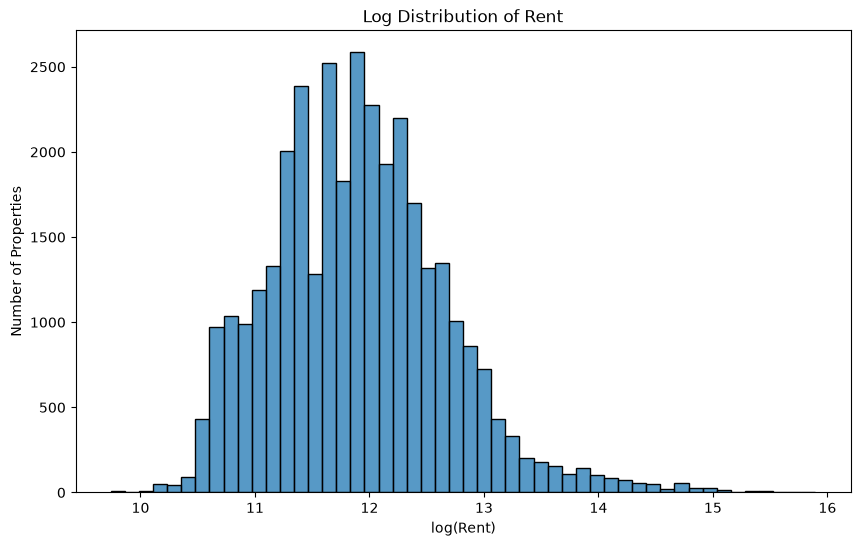

In [79]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(df_model["Rent"]),
    bins=50
)

plt.title("Log Distribution of Rent")
plt.xlabel("log(Rent)")
plt.ylabel("Number of Properties")

plt.show()

In [80]:
model_v4 = Pipeline(
    steps=[
        ("preprocessor", preprocessor_v2),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model_v4.fit(
    X_train_v2,
    np.log1p(y_train_v2)
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Beds','Baths','Type',...,'Furnishing','Location', 'Age_of_listing_in_days']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

In [81]:
y_pred_v4 = np.expm1(
    model_v4.predict(X_test_v2)
)

In [82]:
mae_v4 = mean_absolute_error(y_test_v2, y_pred_v4)
rmse_v4 = np.sqrt(mean_squared_error(y_test_v2, y_pred_v4))
r2_v4 = r2_score(y_test_v2, y_pred_v4)

print(f"MAE: {mae_v4:,.0f} AED")
print(f"RMSE: {rmse_v4:,.0f} AED")
print(f"R²: {r2_v4:.3f}")

MAE: 35,091 AED
RMSE: 118,385 AED
R²: 0.807


In [83]:
results_v3 = pd.DataFrame({
    "Actual_Rent": y_test_v2.values,
    "Predicted_Rent": y_pred_v3
})

results_v3["Absolute_Error"] = (
    results_v3["Actual_Rent"] - results_v3["Predicted_Rent"]
).abs()

results_v3["Rent_Group"] = pd.cut(
    results_v3["Actual_Rent"],
    bins=[0, 100000, 250000, 500000, 1000000, np.inf],
    labels=[
        "0-100K",
        "100K-250K",
        "250K-500K",
        "500K-1M",
        "1M+"
    ]
)

In [84]:
group_performance = results_v3.groupby(
    "Rent_Group",
    observed=True
)["Absolute_Error"].agg(
    ["count", "mean", "median"]
).round(0)

group_performance

,count,mean,median
Rent_Group,,,
0-100K,2295,8049.0,4639.0
100K-250K,3102,19885.0,12041.0
250K-500K,1091,51965.0,31561.0
500K-1M,244,161736.0,106327.0
1M+,108,537351.0,373709.0


In [85]:
results_v3["Absolute_Percentage_Error"] = (
    results_v3["Absolute_Error"] /
    results_v3["Actual_Rent"]
) * 100

In [86]:
percentage_performance = results_v3.groupby(
    "Rent_Group",
    observed=True
)["Absolute_Percentage_Error"].agg(
    ["count", "mean", "median"]
).round(1)

percentage_performance

,count,mean,median
Rent_Group,,,
0-100K,2295,11.7,7.4
100K-250K,3102,12.0,7.8
250K-500K,1091,14.5,9.0
500K-1M,244,22.5,15.3
1M+,108,26.9,24.8


In [87]:
print("========== FINAL MODEL RESULTS ==========")
print("Model: Random Forest Regressor")
print("Target Transformation: log1p(Rent)")
print()
print(f"MAE:  {mae_v3:,.0f} AED")
print(f"RMSE: {rmse_v3:,.0f} AED")
print(f"R²:   {r2_v3:.3f}")
print()
print("Cross-Validation:")
print(f"CV MAE:  {np.mean(cv_mae):,.0f} AED")
print(f"CV RMSE: {np.mean(cv_rmse):,.0f} AED")
print(f"CV R²:   {np.mean(cv_r2):.3f}")

========== FINAL MODEL RESULTS ==========
Model: Random Forest Regressor
Target Transformation: log1p(Rent)

MAE:  34,262 AED
RMSE: 115,848 AED
R²:   0.816

Cross-Validation:
CV MAE:  37,510 AED
CV RMSE: 139,931 AED
CV R²:   0.756


In [88]:
import joblib

joblib.dump(model_v3, "../models/dubai_rent_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [89]:
import joblib
from pathlib import Path

# Save a smaller version of the final model
small_model_path = Path("../models/dubai_rent_model_small.pkl")

joblib.dump(
    model_v3,
    small_model_path,
    compress=9
)

print("Small model saved successfully!")
print(f"File size: {small_model_path.stat().st_size / (1024**2):.2f} MB")

Small model saved successfully!
File size: 41.26 MB
